## 1) Import Lib

In [1]:
from pathlib import Path
import warnings
import json
import sys
import platform

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import sklearn

warnings.filterwarnings("ignore")

## 2) Data

In [2]:
PROJECT_ROOT = Path(r"D:/Study/DATN/hand_gesture_windows_control")

DATA_DIR = PROJECT_ROOT.joinpath("data", "processed", "static")
MODEL_DIR = PROJECT_ROOT.joinpath("models", "checkpoints")
REPORT_DIR = PROJECT_ROOT.joinpath("models", "reports", "model_comparison_ipynb")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR.joinpath("train_static_v1.csv")
VAL_CSV = DATA_DIR.joinpath("val_static_v1.csv")
TEST_CSV = DATA_DIR.joinpath("test_static_v1.csv")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("TRAIN_CSV =", TRAIN_CSV)
print("VAL_CSV   =", VAL_CSV)
print("TEST_CSV  =", TEST_CSV)

PROJECT_ROOT = D:\Study\DATN\hand_gesture_windows_control
TRAIN_CSV = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\train_static_v1.csv
VAL_CSV   = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\val_static_v1.csv
TEST_CSV  = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\test_static_v1.csv


## 2. Load dữ liệu

In [3]:
FEATURE_COLS = [f"f{i}" for i in range(63)]

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

X_train = train_df[FEATURE_COLS].values
y_train = train_df["label"].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df["label"].values

X_test = test_df[FEATURE_COLS].values
y_test = test_df["label"].values

labels = sorted(set(y_train) | set(y_val) | set(y_test))

print("Train:", X_train.shape, len(y_train))
print("Val:  ", X_val.shape, len(y_val))
print("Test: ", X_test.shape, len(y_test))
print("Labels:", labels)

Train: (3025, 63) 3025
Val:   (1030, 63) 1030
Test:  (1051, 63) 1051
Labels: ['fist', 'no_gesture', 'open_palm', 'pinch', 'point', 'two_fingers']


In [4]:
X_train[:1]

array([[ 0.        ,  0.        ,  0.        , -0.17889526, -0.08061599,
        -0.03870525, -0.34192833, -0.37298369, -0.04768515, -0.4085187 ,
        -0.63542175, -0.06600151, -0.43489689, -0.85301846, -0.07523307,
        -0.26030904, -0.7398724 ,  0.04131817, -0.32479832, -0.9281792 ,
        -0.04616209, -0.2983526 , -0.70436138, -0.10739975, -0.25641474,
        -0.49527523, -0.13280408, -0.15123761, -0.78122056,  0.02394647,
        -0.21900167, -0.97361797, -0.06408107, -0.19447821, -0.68342984,
        -0.09579583, -0.15198088, -0.46513748, -0.09030399, -0.02685988,
        -0.7749182 , -0.0107263 , -0.09634602, -0.97444093, -0.10260185,
        -0.08695573, -0.67963016, -0.08634921, -0.05708436, -0.46494997,
        -0.0452048 ,  0.10901178, -0.72439402, -0.04988238,  0.03497037,
        -0.90598774, -0.11632267,  0.01871683, -0.69728148, -0.09516854,
         0.03629063, -0.52095473, -0.05747838]])

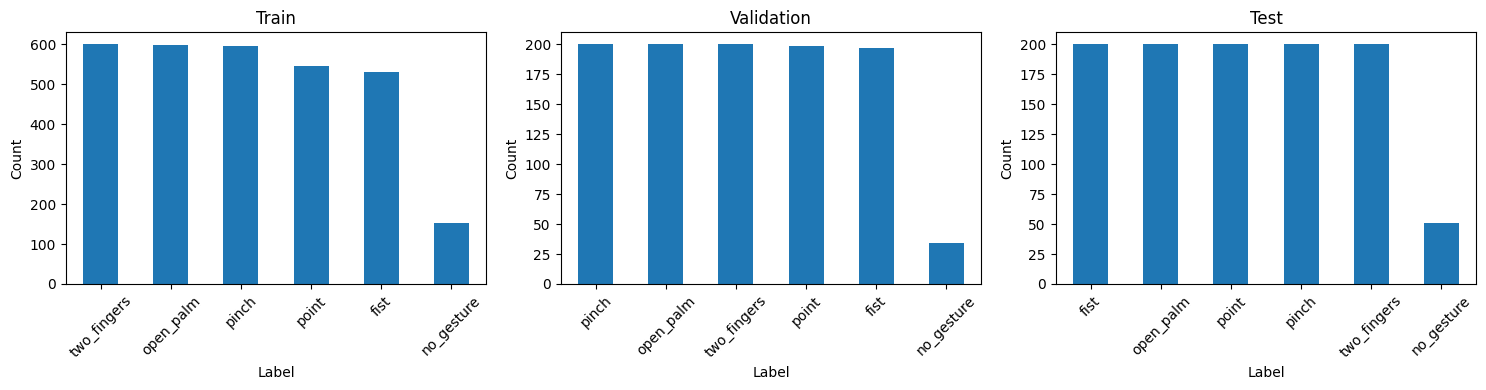

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_df["label"].value_counts().plot(kind="bar", ax=axes[0], title="Train")
val_df["label"].value_counts().plot(kind="bar", ax=axes[1], title="Validation")
test_df["label"].value_counts().plot(kind="bar", ax=axes[2], title="Test")

for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [6]:
display(train_df["label"].value_counts().rename("train_count").to_frame())
display(val_df["label"].value_counts().rename("val_count").to_frame())
display(test_df["label"].value_counts().rename("test_count").to_frame())

,train_count
label,
two_fingers,600
open_palm,599
pinch,597
point,545
fist,531
no_gesture,153


,val_count
label,
pinch,200
open_palm,200
two_fingers,200
point,199
fist,197
no_gesture,34


,test_count
label,
fist,200
open_palm,200
point,200
pinch,200
two_fingers,200
no_gesture,51


## 3. Train Model (SVM, logistic reg, KNN, Random fr, mlp)

In [7]:
models = {
    "svm_rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", class_weight="balanced", probability=True))
    ]),
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "knn": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance"
        ))
    ]),
    "random_forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    # "mlp": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("clf", MLPClassifier(
    #         hidden_layer_sizes=(128, 64),
    #         activation="relu",
    #         solver="adam",
    #         alpha=1e-4,
    #         batch_size=64,
    #         learning_rate_init=1e-3,
    #         max_iter=300,
    #         early_stopping=True,
    #         validation_fraction=0.1,
    #         random_state=42
    #     ))
    # ]),
}

list(models.keys())

['svm_rbf', 'logistic_regression', 'knn', 'random_forest']

In [8]:
# hàm đánh giá model

def evaluate_model(model_name, model, X_val, y_val, X_test, y_test, labels):
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    val_macro_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    val_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    val_report = classification_report(
        y_val, y_val_pred, labels=labels, digits=4, zero_division=0
    )
    test_report = classification_report(
        y_test, y_test_pred, labels=labels, digits=4, zero_division=0
    )

    val_cm = confusion_matrix(y_val, y_val_pred, labels=labels)
    test_cm = confusion_matrix(y_test, y_test_pred, labels=labels)

    return {
        "model_name": model_name,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_macro_f1": val_macro_f1,
        "test_macro_f1": test_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "test_weighted_f1": test_weighted_f1,
        "val_report": val_report,
        "test_report": test_report,
        "val_cm": val_cm,
        "test_cm": test_cm,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
    }

In [9]:
results = {}
summary_rows = []

for model_name, model in models.items():
    print("=" * 80)
    print("Training:", model_name)

    model.fit(X_train, y_train)

    result = evaluate_model(
        model_name=model_name,
        model=model,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        labels=labels,
    )

    results[model_name] = {
        "model": model,
        **result
    }

    summary_rows.append({
        "model": model_name,
        "val_accuracy": round(result["val_acc"], 6),
        "test_accuracy": round(result["test_acc"], 6),
        "val_macro_f1": round(result["val_macro_f1"], 6),
        "test_macro_f1": round(result["test_macro_f1"], 6),
        "val_weighted_f1": round(result["val_weighted_f1"], 6),
        "test_weighted_f1": round(result["test_weighted_f1"], 6),
    })

    print("Validation Accuracy :", round(result["val_acc"], 4))
    print("Test Accuracy       :", round(result["test_acc"], 4))
    print("Validation Macro F1 :", round(result["val_macro_f1"], 4))
    print("Test Macro F1       :", round(result["test_macro_f1"], 4))

Training: svm_rbf
Validation Accuracy : 0.9825
Test Accuracy       : 0.9781
Validation Macro F1 : 0.9791
Test Macro F1       : 0.9567
Training: logistic_regression
Validation Accuracy : 0.9893
Test Accuracy       : 0.9743
Validation Macro F1 : 0.9908
Test Macro F1       : 0.9433
Training: knn
Validation Accuracy : 0.9107
Test Accuracy       : 0.9448
Validation Macro F1 : 0.9229
Test Macro F1       : 0.9062
Training: random_forest
Validation Accuracy : 0.9748
Test Accuracy       : 0.9686
Validation Macro F1 : 0.9783
Test Macro F1       : 0.9406


## 4. Kết quả train

In [10]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["test_macro_f1", "val_macro_f1", "test_accuracy", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

summary_df

,model,val_accuracy,test_accuracy,val_macro_f1,test_macro_f1,val_weighted_f1,test_weighted_f1
0,svm_rbf,0.982524,0.978116,0.979134,0.956748,0.982545,0.976992
1,logistic_regression,0.989320,0.974310,0.990796,0.943308,0.989313,0.972026
2,random_forest,0.974757,0.968601,0.978307,0.940574,0.974790,0.966727
3,knn,0.910680,0.944814,0.922932,0.906187,0.910287,0.941388


In [11]:
best_row = summary_df.iloc[0]
BEST_MODEL_NAME = best_row["model"]

print("=== BEST MODEL ===")
print(best_row)
print("\nChosen model:", BEST_MODEL_NAME)

=== BEST MODEL ===
model                svm_rbf
val_accuracy        0.982524
test_accuracy       0.978116
val_macro_f1        0.979134
test_macro_f1       0.956748
val_weighted_f1     0.982545
test_weighted_f1    0.976992
Name: 0, dtype: object

Chosen model: svm_rbf


In [12]:
summary_csv_path = REPORT_DIR.joinpath("model_comparison_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)
print("Model comparison summary saved to:", summary_csv_path)

Model comparison summary saved to: D:\Study\DATN\hand_gesture_windows_control\models\reports\model_comparison_ipynb\model_comparison_summary.csv


## 5. Classification report từng model

### 5.1) SVM RBF

In [13]:
def classification_report(model_name):
    print("[VALIDATION REPORT]")
    print(results[model_name]["val_report"])

    print("[TEST REPORT]")
    print(results[model_name]["test_report"])

def confusion_matrix(model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["val_cm"],
        display_labels=labels
    ).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{model_name} - Validation")

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["test_cm"],
        display_labels=labels
    ).plot(ax=axes[1], xticks_rotation=45, colorbar=False)
    axes[1].set_title(f"{model_name} - Test")

    plt.tight_layout()
    plt.show()

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9849    0.9949    0.9899       197
  no_gesture     0.9189    1.0000    0.9577        34
   open_palm     0.9479    1.0000    0.9732       200
       pinch     0.9947    0.9450    0.9692       200
       point     1.0000    0.9698    0.9847       199
 two_fingers     1.0000    1.0000    1.0000       200

    accuracy                         0.9825      1030
   macro avg     0.9744    0.9850    0.9791      1030
weighted avg     0.9833    0.9825    0.9825      1030

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9259    1.0000    0.9615       200
  no_gesture     1.0000    0.6863    0.8140        51
   open_palm     0.9898    0.9750    0.9824       200
       pinch     0.9754    0.9900    0.9826       200
       point     1.0000    1.0000    1.0000       200
 two_fingers     1.0000    1.0000    1.0000       200

    accuracy                         0.9781

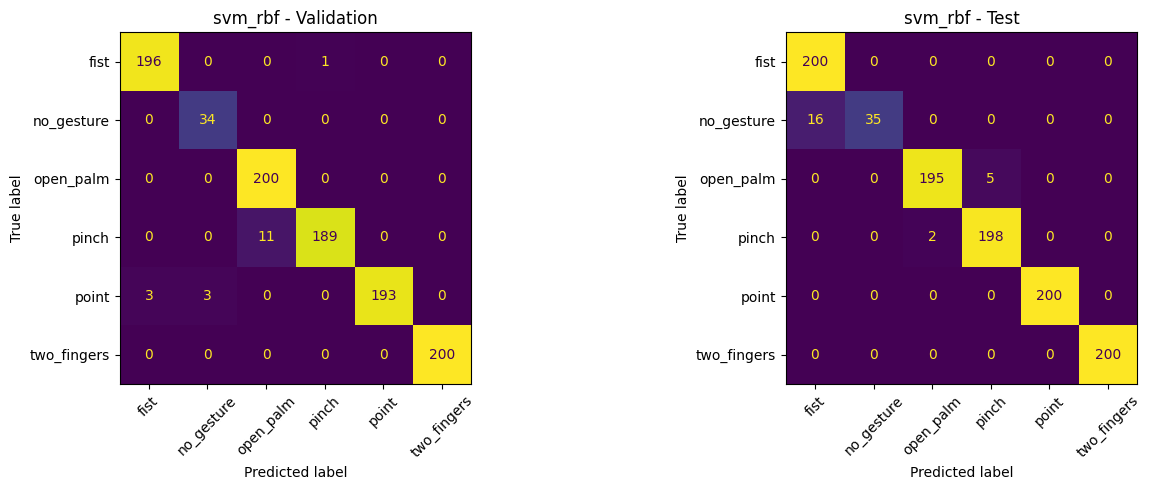

In [14]:
classification_report("svm_rbf")
confusion_matrix("svm_rbf")

### 5.2) Model logistic_regression

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9949    0.9848    0.9898       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.9662    1.0000    0.9828       200
       pinch     0.9948    0.9650    0.9797       200
       point     0.9900    0.9950    0.9925       199
 two_fingers     1.0000    1.0000    1.0000       200

    accuracy                         0.9893      1030
   macro avg     0.9910    0.9908    0.9908      1030
weighted avg     0.9895    0.9893    0.9893      1030

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9519    0.9900    0.9706       200
  no_gesture     1.0000    0.5882    0.7407        51
   open_palm     1.0000    0.9800    0.9899       200
       pinch     0.9804    1.0000    0.9901       200
       point     0.9390    1.0000    0.9685       200
 two_fingers     1.0000    1.0000    1.0000       200

    accuracy                         0.9743

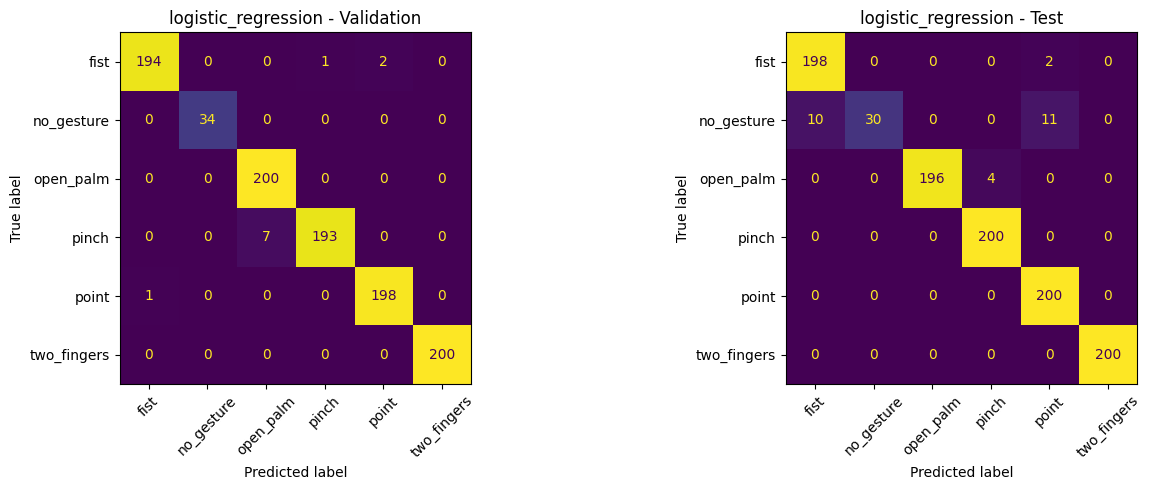

In [15]:
classification_report("logistic_regression")
confusion_matrix("logistic_regression")

### 5.3) Model KNN

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9849    0.9949    0.9899       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.7788    0.8800    0.8263       200
       pinch     0.8571    0.7500    0.8000       200
       point     0.9945    0.9146    0.9529       199
 two_fingers     0.9390    1.0000    0.9685       200

    accuracy                         0.9107      1030
   macro avg     0.9257    0.9232    0.9229      1030
weighted avg     0.9135    0.9107    0.9103      1030

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9238    0.9700    0.9463       200
  no_gesture     1.0000    0.4902    0.6579        51
   open_palm     0.9061    0.9650    0.9346       200
       pinch     0.8916    0.9050    0.8983       200
       point     1.0000    1.0000    1.0000       200
 two_fingers     1.0000    1.0000    1.0000       200

    accuracy                         0.9448

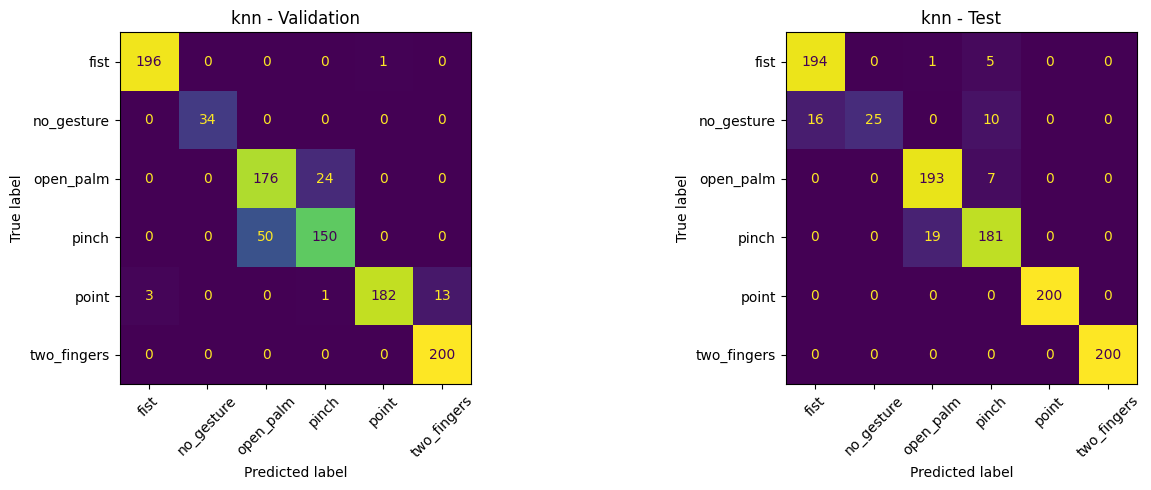

In [16]:
classification_report("knn")
confusion_matrix("knn")

### 5.4) Model random forest

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9798    0.9848    0.9823       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.9327    0.9700    0.9510       200
       pinch     0.9639    0.9350    0.9492       200
       point     0.9949    0.9799    0.9873       199
 two_fingers     1.0000    1.0000    1.0000       200

    accuracy                         0.9748      1030
   macro avg     0.9786    0.9783    0.9783      1030
weighted avg     0.9751    0.9748    0.9748      1030

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9091    1.0000    0.9524       200
  no_gesture     1.0000    0.6078    0.7561        51
   open_palm     0.9895    0.9450    0.9668       200
       pinch     0.9474    0.9900    0.9682       200
       point     1.0000    1.0000    1.0000       200
 two_fingers     1.0000    1.0000    1.0000       200

    accuracy                         0.9686

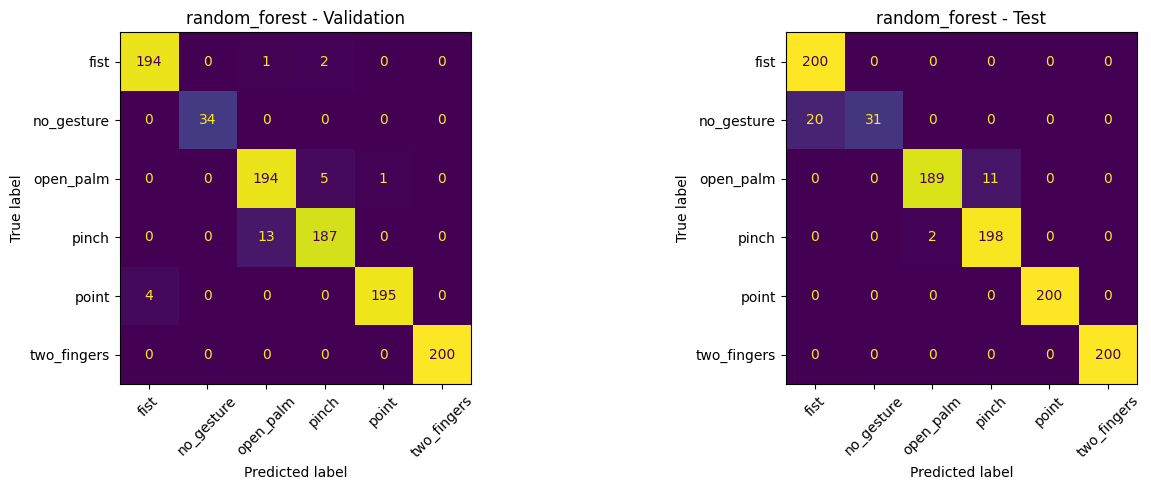

In [17]:
classification_report("random_forest")
confusion_matrix("random_forest")

## 6. Lưu model và báo cáo

In [18]:

print(labels)

['fist', 'no_gesture', 'open_palm', 'pinch', 'point', 'two_fingers']


In [19]:
BEST_MODEL_NAME = summary_df.iloc[0]["model"]

BEST_MODEL_PATH = MODEL_DIR / "static_best_model.joblib"
BEST_META_PATH = MODEL_DIR / "static_best_model_meta.json"

best_model = results[BEST_MODEL_NAME]["model"]

joblib.dump(best_model, BEST_MODEL_PATH)

meta = {
    "best_model": BEST_MODEL_NAME,
    "labels": labels,
    "feature_columns": FEATURE_COLS,
    "feature_dim": len(FEATURE_COLS),
    "val_accuracy": float(results[BEST_MODEL_NAME]["val_acc"]),
    "test_accuracy": float(results[BEST_MODEL_NAME]["test_acc"]),
    "val_macro_f1": float(results[BEST_MODEL_NAME]["val_macro_f1"]),
    "test_macro_f1": float(results[BEST_MODEL_NAME]["test_macro_f1"]),
    "data_files": {
        "train_csv": str(TRAIN_CSV),
        "val_csv": str(VAL_CSV),
        "test_csv": str(TEST_CSV),
    },
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "sklearn": sklearn.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
    "note": "Best model chosen by highest test_macro_f1, then val_macro_f1, then accuracy."
}

BEST_META_PATH.write_text(
    json.dumps(meta, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Saved model to:", BEST_MODEL_PATH)
print("Saved metadata to:", BEST_META_PATH)
print("Best model name:", BEST_MODEL_NAME)

Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_best_model.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_best_model_meta.json
Best model name: svm_rbf


In [ ]:
# # Save best final model for deployment
# BEST_MODEL_NAME = 'svm_rbf'
# BEST_MODEL_PATH = PROJECT_ROOT / 'models' / 'checkpoints'/ 'static_svm_rbf.joblib'
# BEST_META_PATH = PROJECT_ROOT / 'models' / 'reports' / 'static_svm_rbf_meta.json'

# best_model = results[BEST_MODEL_NAME]['model']

# import joblib
# joblib.dump(best_model, BEST_MODEL_PATH)

# import json
# meta = {
#     'best_model': BEST_MODEL_NAME,
#     'labels': labels,
#     'val_accuracy': float(results[BEST_MODEL_NAME]['val_acc']),
#     'test_accuracy': float(results[BEST_MODEL_NAME]['test_acc']),
#     'feature_columns': FEATURE_COLS,
#     'note': 'Chosen by highest test accuracy and better generalization than logistic_regression'
# }

# BEST_META_PATH.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

# print('Saved model to:', BEST_MODEL_PATH)
# print('Saved metadata to:', BEST_META_PATH)

Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_svm_rbf.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\reports\static_svm_rbf_meta.json
